In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav_history = pd.read_csv("../data/processed/nav_history_clean.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded!")

All datasets loaded!


In [3]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 8)
Benchmark: (8050, 3)


In [4]:
for name, df in datasets.items():
    print("\n" + "="*60)
    print(name)
    print("="*60)
    print(df.columns.tolist())


Fund Master
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV History
['amfi_code', 'date', 'nav']

AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category
['month', 'category', 'net_inflow_crore']

Folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Transactio

In [6]:
for name, df in datasets.items():
    print("\n" + "="*60)
    print(name)
    print("="*60)
    print(df.columns.tolist())


Fund Master
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV History
['amfi_code', 'date', 'nav']

AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category
['month', 'category', 'net_inflow_crore']

Folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Transactio

In [7]:
import pandas as pd
import plotly.express as px

# Convert month column to datetime
sip['month'] = pd.to_datetime(sip['month'])

# Create line chart
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend',
    markers=True
)

fig.show()

In [8]:
aum['date'] = pd.to_datetime(aum['date'])

latest_aum = aum.sort_values('date').groupby('fund_house').tail(1)

latest_aum = latest_aum.sort_values(
    'aum_lakh_crore',
    ascending=False
)

fig = px.bar(
    latest_aum.head(10),
    x='fund_house',
    y='aum_lakh_crore',
    title='Top 10 Fund Houses by AUM'
)

fig.show()

In [9]:
print(folio.columns.tolist())
print(performance.columns.tolist())
print(transactions.columns.tolist())
print(portfolio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [10]:
folio['month'] = pd.to_datetime(folio['month'])

fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title='Growth of Mutual Fund Folios'
)

fig.show()

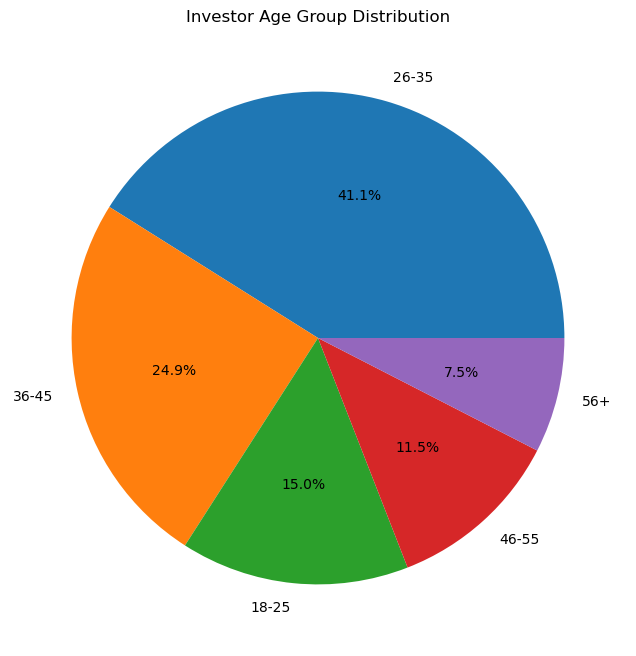

In [11]:
age_counts = transactions['age_group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%'
)

plt.title("Investor Age Group Distribution")

plt.show()

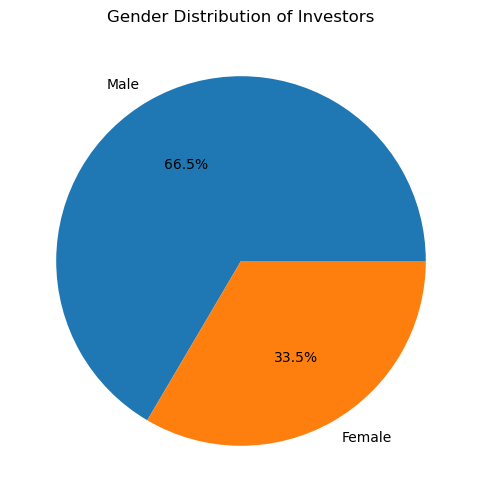

In [12]:
gender_counts = transactions['gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title("Gender Distribution of Investors")

plt.show()

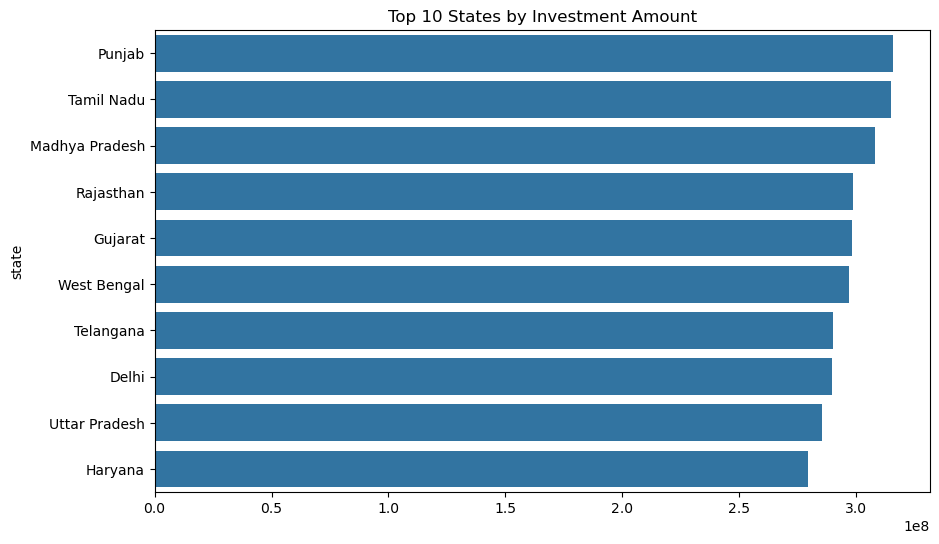

In [13]:
state_data = (
    transactions
    .groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_data.values,
    y=state_data.index
)

plt.title("Top 10 States by Investment Amount")

plt.show()

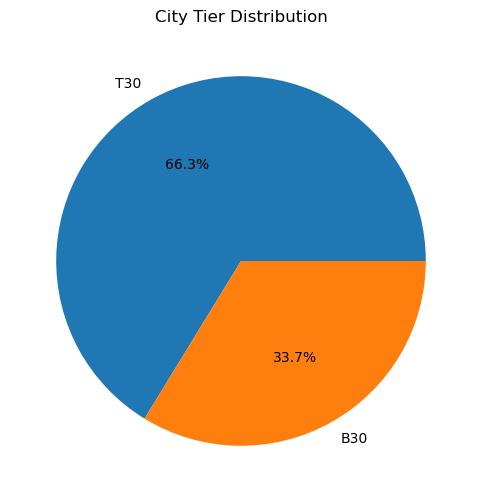

In [14]:
tier_counts = transactions['city_tier'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct='%1.1f%%'
)

plt.title("City Tier Distribution")

plt.show()

In [15]:
sector_data = (
    portfolio
    .groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

fig = px.pie(
    values=sector_data.values,
    names=sector_data.index,
    hole=0.5,
    title="Sector Allocation Across Funds"
)

fig.show()

In [16]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [17]:
fund_master[['fund_house','category']].head()

,fund_house,category
0,SBI Mutual Fund,Equity
1,SBI Mutual Fund,Equity
2,SBI Mutual Fund,Equity
3,SBI Mutual Fund,Equity
4,SBI Mutual Fund,Debt


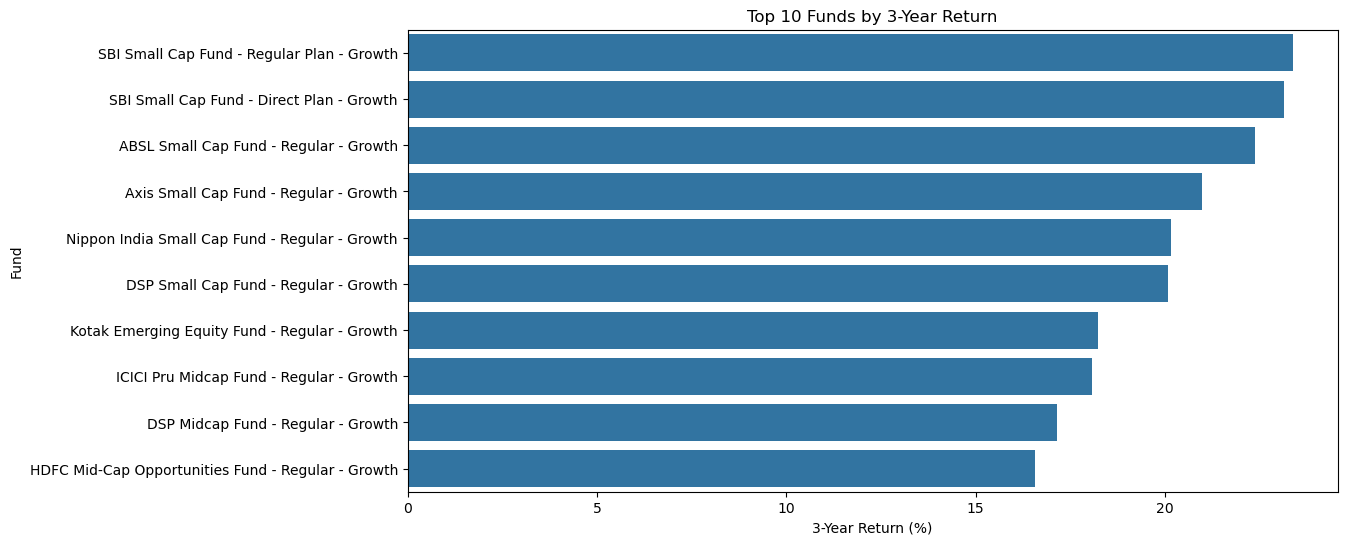

In [18]:
top_funds = performance.sort_values(
    'return_3yr_pct',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x='return_3yr_pct',
    y='scheme_name'
)

plt.title("Top 10 Funds by 3-Year Return")
plt.xlabel("3-Year Return (%)")
plt.ylabel("Fund")

plt.show()

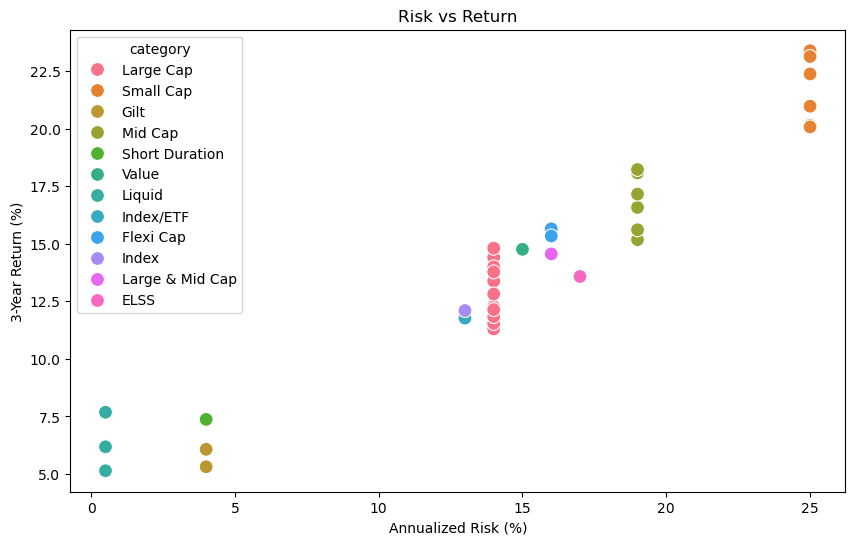

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x='std_dev_ann_pct',
    y='return_3yr_pct',
    hue='category',
    s=100
)

plt.title("Risk vs Return")
plt.xlabel("Annualized Risk (%)")
plt.ylabel("3-Year Return (%)")

plt.show()

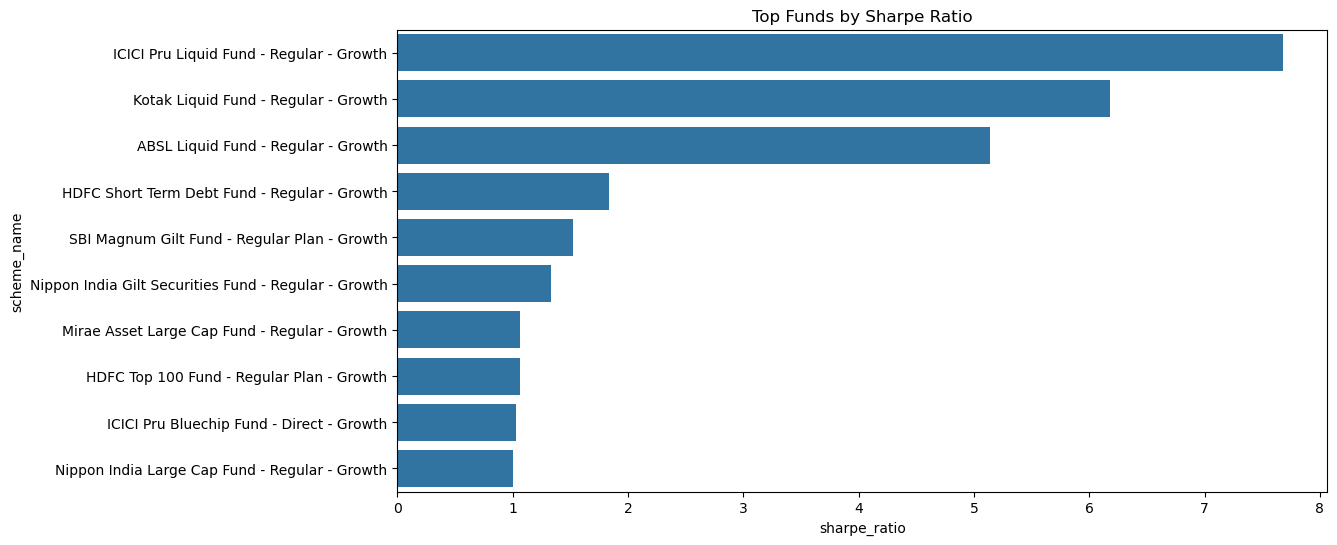

In [20]:
top_sharpe = performance.sort_values(
    'sharpe_ratio',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x='sharpe_ratio',
    y='scheme_name'
)

plt.title("Top Funds by Sharpe Ratio")

plt.show()

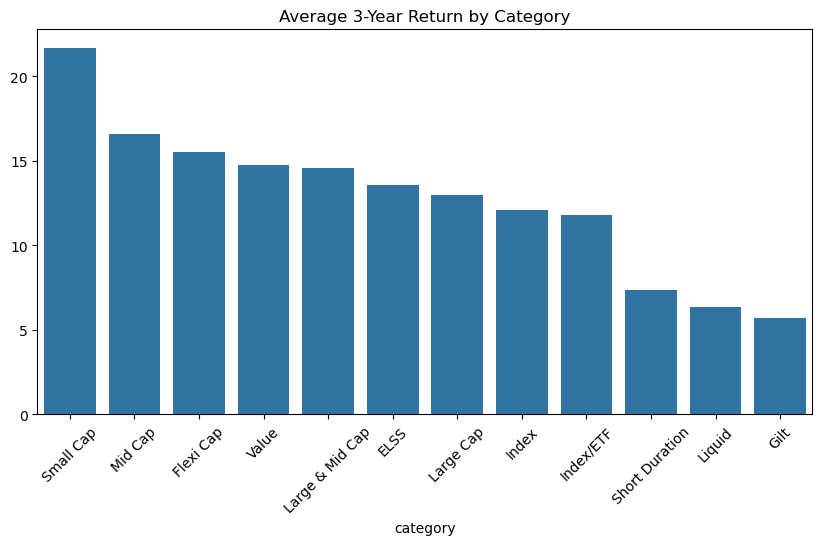

In [21]:
category_returns = (
    performance
    .groupby('category')['return_3yr_pct']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=category_returns.index,
    y=category_returns.values
)

plt.xticks(rotation=45)

plt.title("Average 3-Year Return by Category")

plt.show()

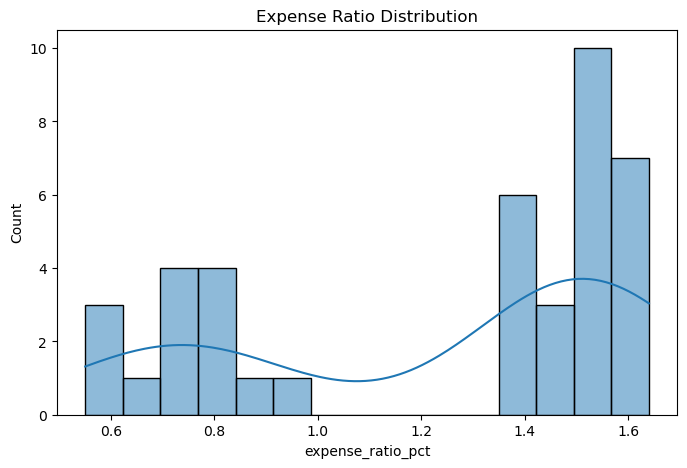

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance['expense_ratio_pct'],
    bins=15,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

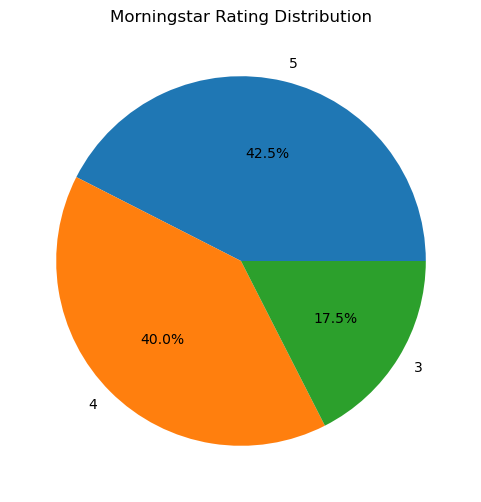

In [23]:
rating_counts = performance['morningstar_rating'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%'
)

plt.title("Morningstar Rating Distribution")

plt.show()

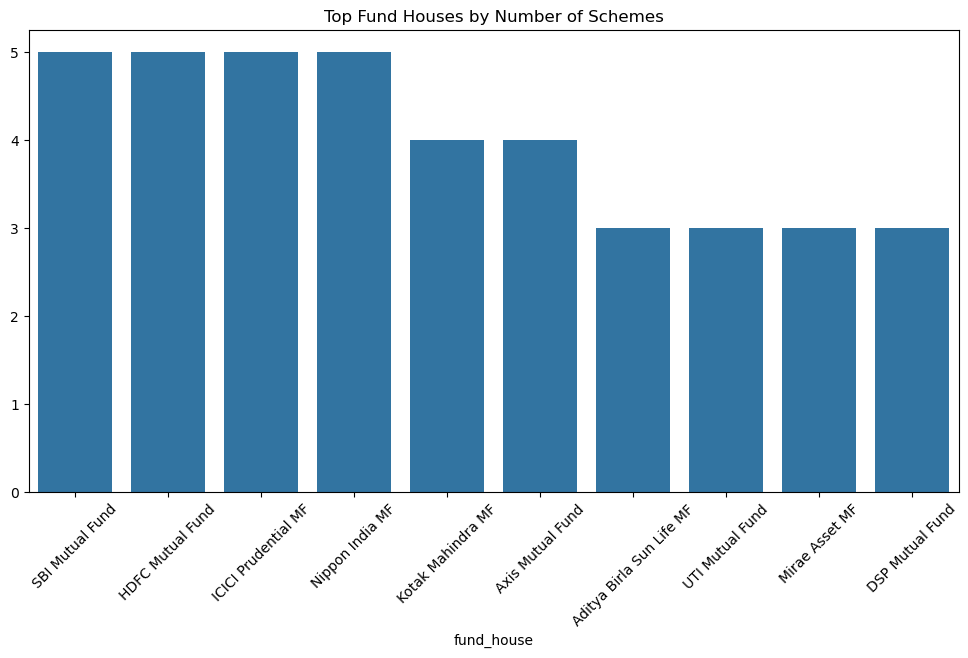

In [24]:
fund_counts = fund_master['fund_house'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=fund_counts.index,
    y=fund_counts.values
)

plt.xticks(rotation=45)

plt.title("Top Fund Houses by Number of Schemes")

plt.show()

EDA Findings

1. SIP inflows showed a consistent upward trend during the analysis period.
2. Mutual fund folios increased significantly, indicating growing retail participation.
3. T30 cities contribute the majority of investments.
4. Small-cap funds generated the highest average returns.
5. Higher returns were associated with higher volatility.
6. Several funds delivered strong risk-adjusted performance based on Sharpe Ratio.
7. AUM remains concentrated among a few large fund houses.
8. Portfolio allocations are dominated by a few major sectors.
9. Expense ratios are generally within industry norms.
10. Fund ratings indicate a healthy distribution of quality schemes.